# Droneport Görev Enerjisi İçin Makine Öğrenmesi Modellerinin Geliştirilmesi

## Çalışmanın Amacı

Bu Notebook'ta, önceki veri üretimi ve temizleme aşamasında hazırlanan sabit veri kümesi kullanılarak İHA görevlerinin enerji ihtiyacını tahmin eden makine öğrenmesi modelleri geliştirilecektir.

İlk olarak temiz veri kümesi Google Drive üzerinden yüklenecek ve dosya bütünlüğü SHA-256 değeri kullanılarak doğrulanacaktır. Daha sonra model giriş özellikleri ve hedef değişken belirlenecek, veriler eğitim ve test kümelerine ayrılacaktır.

Çalışma kapsamında bir temel tahmin modeli ile birlikte doğrusal regresyon, karar ağacı, rastgele orman ve gradyan artırma modelleri değerlendirilecektir. Modellerin tahmin başarıları MAE, RMSE ve R² ölçütleri kullanılarak karşılaştırılacaktır. En başarılı model üzerinde hiperparametre optimizasyonu ve hata analizi gerçekleştirilecektir.


In [1]:
# Dosya işlemleri ve veri analizi için gerekli kütüphaneler içe aktarılıyor.
from pathlib import Path
import hashlib
import random
import warnings

import numpy as np
import pandas as pd
import sklearn

from google.colab import drive
from IPython.display import display

# Gereksiz uyarıların Notebook çıktısında gösterilmesi engelleniyor.
warnings.filterwarnings("ignore")

# Sonuçların tekrar üretilebilir olması için sabit rastgelelik değeri tanımlanıyor.
RASTGELELIK_DEGERI = 42
random.seed(RASTGELELIK_DEGERI)
np.random.seed(RASTGELELIK_DEGERI)

# Google Drive daha önce bağlanmadıysa bağlantı kuruluyor.
if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

# Projede kullanılacak klasör yolları tanımlanıyor.
PROJE_KLASORU = Path(
    "/content/drive/MyDrive/Droneport_Enerji_Optimizasyonu"
)

VERI_KLASORU = PROJE_KLASORU / "veri"
GRAFIK_KLASORU = PROJE_KLASORU / "grafikler"
MODEL_KLASORU = PROJE_KLASORU / "modeller"
SONUC_KLASORU = PROJE_KLASORU / "sonuclar"

# Temiz veri kümesinin dosya yolu tanımlanıyor.
TEMIZ_VERI_DOSYASI = (
    VERI_KLASORU / "droneport_temiz_gorev_verileri.csv"
)

# Önceki Notebook'ta kaydedilen referans SHA-256 değeri tanımlanıyor.
BEKLENEN_TEMIZ_VERI_SHA256 = (
    "9f17742ad94c53746e5486d0b86d7506d120c50fd68ddc7e57f93ba5fa043b27"
)

# Veri dosyasının mevcut olup olmadığı kontrol ediliyor.
if not TEMIZ_VERI_DOSYASI.exists():
    raise FileNotFoundError(
        f"Temiz veri dosyası bulunamadı: {TEMIZ_VERI_DOSYASI}"
    )

# Dosyanın güncel SHA-256 değeri hesaplanıyor.
sha256_hesaplayici = hashlib.sha256()

with open(TEMIZ_VERI_DOSYASI, "rb") as veri_dosyasi:
    for veri_blogu in iter(
        lambda: veri_dosyasi.read(8192),
        b""
    ):
        sha256_hesaplayici.update(veri_blogu)

hesaplanan_temiz_veri_sha256 = sha256_hesaplayici.hexdigest()

# Hesaplanan özet değeri referans değerle karşılaştırılıyor.
dosya_butunlugu_dogrulandi = (
    hesaplanan_temiz_veri_sha256
    == BEKLENEN_TEMIZ_VERI_SHA256
)

if not dosya_butunlugu_dogrulandi:
    raise ValueError(
        "Temiz veri dosyasının SHA-256 değeri beklenen değerle eşleşmedi. "
        "Dosya değiştirilmiş olabilir."
    )

# Doğrulanan temiz veri kümesi belleğe yükleniyor.
temiz_gorev_verileri = pd.read_csv(
    TEMIZ_VERI_DOSYASI,
    encoding="utf-8-sig"
)

# Veri kümesinin temel yapısal kontrolleri gerçekleştiriliyor.
beklenen_sutunlar = [
    "gorev_no",
    "gorev_mesafesi_km",
    "ortalama_ucus_hizi_kmh",
    "operasyon_suresi_dk",
    "toplam_gorev_suresi_dk",
    "faydali_yuk_kg",
    "ruzgar_hizi_mps",
    "ortam_sicakligi_c",
    "baslangic_batarya_yuzde",
    "sarj_dongusu_sayisi",
    "batarya_sagligi_yuzde",
    "batarya_sicakligi_c",
    "gerekli_enerji_wh"
]

sutun_yapisi_dogrulandi = (
    temiz_gorev_verileri.columns.tolist()
    == beklenen_sutunlar
)

if not sutun_yapisi_dogrulandi:
    raise ValueError(
        "Veri kümesinin sütun yapısı beklenen yapıyla eşleşmedi."
    )

# Yükleme ve doğrulama sonuçları görüntüleniyor.
print("TEMİZ VERİ KÜMESİ BAŞARIYLA YÜKLENDİ")
print("=" * 72)
print(f"Dosya adı                  : {TEMIZ_VERI_DOSYASI.name}")
print(f"Veri kümesi boyutu         : {temiz_gorev_verileri.shape}")
print(
    f"Toplam eksik değer         : "
    f"{temiz_gorev_verileri.isna().sum().sum()}"
)
print(
    f"Tekrarlanan görev numarası : "
    f"{temiz_gorev_verileri['gorev_no'].duplicated().sum()}"
)
print(f"Sütun yapısı doğrulandı    : {sutun_yapisi_dogrulandi}")
print(f"Dosya bütünlüğü doğrulandı : {dosya_butunlugu_dogrulandi}")
print(f"Scikit-learn sürümü        : {sklearn.__version__}")
print(f"SHA-256                    : {hesaplanan_temiz_veri_sha256}")

print("\nVERİ KÜMESİNDEKİ İLK BEŞ GÖREV")
print("=" * 72)
display(temiz_gorev_verileri.head())


Mounted at /content/drive
TEMİZ VERİ KÜMESİ BAŞARIYLA YÜKLENDİ
Dosya adı                  : droneport_temiz_gorev_verileri.csv
Veri kümesi boyutu         : (4997, 13)
Toplam eksik değer         : 0
Tekrarlanan görev numarası : 0
Sütun yapısı doğrulandı    : True
Dosya bütünlüğü doğrulandı : True
Scikit-learn sürümü        : 1.6.1
SHA-256                    : 9f17742ad94c53746e5486d0b86d7506d120c50fd68ddc7e57f93ba5fa043b27

VERİ KÜMESİNDEKİ İLK BEŞ GÖREV


,gorev_no,gorev_mesafesi_km,ortalama_ucus_hizi_kmh,operasyon_suresi_dk,toplam_gorev_suresi_dk,faydali_yuk_kg,ruzgar_hizi_mps,ortam_sicakligi_c,baslangic_batarya_yuzde,sarj_dongusu_sayisi,batarya_sagligi_yuzde,batarya_sicakligi_c,gerekli_enerji_wh
0,1,10.39,44.34,1.42,15.48,0.57,2.14,8.62,82.47,213.0,89.96,19.79,148.26
1,2,8.13,20.00,8.57,32.96,0.84,8.93,9.60,84.43,187.0,88.81,15.02,418.59
2,3,11.07,38.14,7.90,25.31,0.64,0.63,4.82,79.96,135.0,95.03,9.29,268.61
3,4,5.49,33.04,7.90,17.87,0.15,2.34,3.29,88.27,71.0,97.15,4.10,172.56
4,5,15.59,28.90,3.01,35.39,0.75,4.55,10.21,87.43,86.0,95.66,16.61,323.47


## 1. Makine Öğrenmesi İçin Veri Hazırlama

Makine öğrenmesi modellerinin amacı, görev ve çevre koşullarını kullanarak gerekli enerji miktarını tahmin etmektir. Bu nedenle görev numarası, başlangıç batarya seviyesi, batarya sağlığı ve şarj döngüsü sayısı model girdilerine dahil edilmemiştir.

Başlangıç batarya seviyesi ve batarya sağlığı, görevin ihtiyaç duyduğu enerjiyi doğrudan belirlemek yerine mevcut enerjinin görev için yeterli olup olmadığının değerlendirilmesinde kullanılacaktır. Bu değişkenler projenin karar destek aşamasında ayrıca ele alınacaktır.

Temiz veri kümesinin %80'i eğitim, %20'si test amacıyla ayrılmıştır. Düşük ve yüksek enerji ihtiyacına sahip görevlerin iki veri kümesinde de benzer oranlarda bulunması amacıyla hedef değişken geçici yüzdelik gruplara ayrılmış ve tabakalı veri bölme yöntemi uygulanmıştır. Bu gruplar yalnızca dengeli veri bölme amacıyla kullanılmış, model girdilerine dahil edilmemiştir.


In [2]:
# Eğitim ve test verilerinin ayrılması için gerekli araç içe aktarılıyor.
from sklearn.model_selection import train_test_split

# Enerji tahmininde kullanılacak giriş özellikleri belirleniyor.
model_ozellikleri = [
    "gorev_mesafesi_km",
    "ortalama_ucus_hizi_kmh",
    "operasyon_suresi_dk",
    "toplam_gorev_suresi_dk",
    "faydali_yuk_kg",
    "ruzgar_hizi_mps",
    "ortam_sicakligi_c",
    "batarya_sicakligi_c"
]

# Modelin tahmin edeceği hedef değişken belirleniyor.
hedef_degisken = "gerekli_enerji_wh"

# Girdi özellikleri ve hedef değişken temiz veri kümesinden ayrılıyor.
X = temiz_gorev_verileri[
    model_ozellikleri
].copy()

y = temiz_gorev_verileri[
    hedef_degisken
].copy()

# Görev numaraları, test sonuçlarının izlenebilmesi için ayrı olarak korunuyor.
gorev_numaralari = temiz_gorev_verileri[
    "gorev_no"
].astype(int).copy()

# Enerji dağılımının eğitim ve test kümelerinde korunması için
# hedef değişken geçici olarak on yüzdelik gruba ayrılıyor.
enerji_tabakalari = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

# Veriler %80 eğitim ve %20 test olacak biçimde ayrılıyor.
# Görev numaraları ve enerji tabakaları da aynı indekslerle bölünüyor.
(
    X_egitim,
    X_test,
    y_egitim,
    y_test,
    gorev_no_egitim,
    gorev_no_test,
    enerji_tabakasi_egitim,
    enerji_tabakasi_test
) = train_test_split(
    X,
    y,
    gorev_numaralari,
    enerji_tabakalari,
    test_size=0.20,
    random_state=RASTGELELIK_DEGERI,
    stratify=enerji_tabakalari
)

# Eğitim ve test kümelerinin hedef değişken istatistikleri hazırlanıyor.
hedef_dagilim_karsilastirmasi = pd.DataFrame({
    "Veri Kümesi": [
        "Eğitim",
        "Test"
    ],
    "Kayıt Sayısı": [
        len(y_egitim),
        len(y_test)
    ],
    "Ortalama Enerji (Wh)": [
        y_egitim.mean(),
        y_test.mean()
    ],
    "Standart Sapma (Wh)": [
        y_egitim.std(),
        y_test.std()
    ],
    "En Düşük Enerji (Wh)": [
        y_egitim.min(),
        y_test.min()
    ],
    "Medyan Enerji (Wh)": [
        y_egitim.median(),
        y_test.median()
    ],
    "En Yüksek Enerji (Wh)": [
        y_egitim.max(),
        y_test.max()
    ]
})

sayisal_ozet_sutunlari = [
    "Ortalama Enerji (Wh)",
    "Standart Sapma (Wh)",
    "En Düşük Enerji (Wh)",
    "Medyan Enerji (Wh)",
    "En Yüksek Enerji (Wh)"
]

hedef_dagilim_karsilastirmasi[
    sayisal_ozet_sutunlari
] = hedef_dagilim_karsilastirmasi[
    sayisal_ozet_sutunlari
].round(2)

# Eğitim ve test kümelerinde ortak görev bulunup bulunmadığı kontrol ediliyor.
ortak_gorev_sayisi = len(
    set(gorev_no_egitim).intersection(
        set(gorev_no_test)
    )
)

# Tabakaların eğitim ve test kümelerindeki oranları karşılaştırılıyor.
tabaka_karsilastirmasi = pd.concat(
    [
        enerji_tabakasi_egitim.value_counts(
            normalize=True
        ).sort_index().rename("Eğitim Oranı"),
        enerji_tabakasi_test.value_counts(
            normalize=True
        ).sort_index().rename("Test Oranı")
    ],
    axis=1
).reset_index()

tabaka_karsilastirmasi.columns = [
    "Enerji Tabakası",
    "Eğitim Oranı",
    "Test Oranı"
]

tabaka_karsilastirmasi[
    ["Eğitim Oranı", "Test Oranı"]
] = (
    tabaka_karsilastirmasi[
        ["Eğitim Oranı", "Test Oranı"]
    ]
    * 100
).round(2)

print("MAKİNE ÖĞRENMESİ VERİ HAZIRLAMA SONUÇLARI")
print("=" * 72)
print(f"Toplam kullanılabilir kayıt   : {len(X)}")
print(f"Girdi özelliği sayısı         : {X.shape[1]}")
print(f"Eğitim kaydı sayısı           : {len(X_egitim)}")
print(f"Test kaydı sayısı             : {len(X_test)}")
print(f"Eğitim-test ortak görevi      : {ortak_gorev_sayisi}")
print(
    f"Eğitim verisindeki eksik değer: "
    f"{X_egitim.isna().sum().sum()}"
)
print(
    f"Test verisindeki eksik değer  : "
    f"{X_test.isna().sum().sum()}"
)

print("\nMODEL GİRDİ ÖZELLİKLERİ")
print("=" * 72)

for sira, ozellik in enumerate(
    model_ozellikleri,
    start=1
):
    print(f"{sira}. {ozellik}")

print("\nEĞİTİM VE TEST HEDEF DAĞILIMLARI")
print("=" * 72)
display(hedef_dagilim_karsilastirmasi)

print("\nENERJİ TABAKALARININ YÜZDELİK DAĞILIMI")
print("=" * 72)
display(tabaka_karsilastirmasi)


MAKİNE ÖĞRENMESİ VERİ HAZIRLAMA SONUÇLARI
Toplam kullanılabilir kayıt   : 4997
Girdi özelliği sayısı         : 8
Eğitim kaydı sayısı           : 3997
Test kaydı sayısı             : 1000
Eğitim-test ortak görevi      : 0
Eğitim verisindeki eksik değer: 0
Test verisindeki eksik değer  : 0

MODEL GİRDİ ÖZELLİKLERİ
1. gorev_mesafesi_km
2. ortalama_ucus_hizi_kmh
3. operasyon_suresi_dk
4. toplam_gorev_suresi_dk
5. faydali_yuk_kg
6. ruzgar_hizi_mps
7. ortam_sicakligi_c
8. batarya_sicakligi_c

EĞİTİM VE TEST HEDEF DAĞILIMLARI


,Veri Kümesi,Kayıt Sayısı,Ortalama Enerji (Wh),Standart Sapma (Wh),En Düşük Enerji (Wh),Medyan Enerji (Wh),En Yüksek Enerji (Wh)
0,Eğitim,3997,193.33,79.15,37.40,182.15,599.86
1,Test,1000,193.71,79.71,40.39,182.06,661.41



ENERJİ TABAKALARININ YÜZDELİK DAĞILIMI


,Enerji Tabakası,Eğitim Oranı,Test Oranı
0,0,10.01,10.0
1,1,10.01,10.0
2,2,10.01,10.0
3,3,9.98,10.0
4,4,10.01,10.0
5,5,9.98,10.0
6,6,10.01,10.0
7,7,9.98,10.0
8,8,10.01,10.0
9,9,10.01,10.0


## 2. Temel Tahmin Modellerinin Oluşturulması

Geliştirilecek makine öğrenmesi modellerinin sağladığı iyileşmenin ölçülebilmesi için iki temel tahmin yaklaşımı oluşturulmuştur.

İlk yaklaşımda bütün test görevleri için eğitim kümesindeki ortalama enerji değeri tahmin edilmiştir. Bu model, görev koşullarını dikkate almayan en basit karşılaştırma noktasıdır.

İkinci yaklaşımda yalnızca toplam görev süresi kullanılarak doğrusal regresyon modeli eğitilmiştir. Toplam görev süresi enerji ihtiyacıyla güçlü bir ilişkiye sahip olduğundan, diğer görev ve çevre değişkenlerinin gerçekten ek tahmin değeri sağlayıp sağlamadığı bu model üzerinden değerlendirilecektir.

Model başarıları aşağıdaki ölçütlerle incelenmiştir:

- **MAE:** Tahmin hatalarının mutlak değerlerinin ortalamasıdır.
- **RMSE:** Büyük tahmin hatalarına daha fazla ağırlık veren hata ölçütüdür.
- **R²:** Modelin hedef değişkendeki değişimin ne kadarını açıklayabildiğini gösterir.


In [3]:
# Temel tahmin modelleri ve değerlendirme ölçütleri içe aktarılıyor.
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# Model sonuçlarının aynı biçimde hesaplanması için yardımcı fonksiyon tanımlanıyor.
def regresyon_sonuclarini_hesapla(
    model_adi,
    gercek_degerler,
    tahminler
):
    """
    Bir regresyon modelinin MAE, RMSE ve R² sonuçlarını hesaplar.
    """

    return {
        "Model": model_adi,
        "MAE (Wh)": mean_absolute_error(
            gercek_degerler,
            tahminler
        ),
        "RMSE (Wh)": root_mean_squared_error(
            gercek_degerler,
            tahminler
        ),
        "R²": r2_score(
            gercek_degerler,
            tahminler
        )
    }

# Birinci temel model, bütün görevler için eğitim hedefinin ortalamasını tahmin ediyor.
ortalama_temel_modeli = DummyRegressor(
    strategy="mean"
)

ortalama_temel_modeli.fit(
    X_egitim,
    y_egitim
)

ortalama_temel_tahminleri = (
    ortalama_temel_modeli.predict(X_test)
)

# İkinci temel modelde yalnızca toplam görev süresi kullanılıyor.
sure_ozelligi = [
    "toplam_gorev_suresi_dk"
]

sure_temel_modeli = LinearRegression()

sure_temel_modeli.fit(
    X_egitim[sure_ozelligi],
    y_egitim
)

sure_temel_tahminleri = sure_temel_modeli.predict(
    X_test[sure_ozelligi]
)

# İki temel modelin test sonuçları hesaplanıyor.
temel_model_sonuclari = pd.DataFrame([
    regresyon_sonuclarini_hesapla(
        "Ortalama Tahmin Modeli",
        y_test,
        ortalama_temel_tahminleri
    ),
    regresyon_sonuclarini_hesapla(
        "Yalnızca Görev Süresi Modeli",
        y_test,
        sure_temel_tahminleri
    )
])

# Sonuç tablosundaki sayısal değerler okunabilir biçimde yuvarlanıyor.
temel_model_sonuclari[
    ["MAE (Wh)", "RMSE (Wh)", "R²"]
] = temel_model_sonuclari[
    ["MAE (Wh)", "RMSE (Wh)", "R²"]
].round(4)

# Görev süresi modelinin doğrusal denklemi elde ediliyor.
sure_modeli_katsayisi = float(
    sure_temel_modeli.coef_[0]
)

sure_modeli_sabit_degeri = float(
    sure_temel_modeli.intercept_
)

# Test kümesinden örnek tahmin tablosu hazırlanıyor.
temel_tahmin_ornekleri = pd.DataFrame({
    "Görev No": gorev_no_test.astype(int).values,
    "Toplam Görev Süresi (dk)": (
        X_test["toplam_gorev_suresi_dk"].values
    ),
    "Gerçek Enerji (Wh)": y_test.values,
    "Ortalama Model Tahmini (Wh)": (
        ortalama_temel_tahminleri
    ),
    "Süre Modeli Tahmini (Wh)": (
        sure_temel_tahminleri
    )
})

temel_tahmin_ornekleri[
    [
        "Toplam Görev Süresi (dk)",
        "Gerçek Enerji (Wh)",
        "Ortalama Model Tahmini (Wh)",
        "Süre Modeli Tahmini (Wh)"
    ]
] = temel_tahmin_ornekleri[
    [
        "Toplam Görev Süresi (dk)",
        "Gerçek Enerji (Wh)",
        "Ortalama Model Tahmini (Wh)",
        "Süre Modeli Tahmini (Wh)"
    ]
].round(2)

print("TEMEL MODEL DEĞERLENDİRME SONUÇLARI")
print("=" * 72)
display(temel_model_sonuclari)

print("\nGÖREV SÜRESİ MODELİNİN DOĞRUSAL DENKLEMİ")
print("=" * 72)
print(
    "Tahmini Enerji (Wh) = "
    f"{sure_modeli_sabit_degeri:.4f} + "
    f"({sure_modeli_katsayisi:.4f} × Toplam Görev Süresi)"
)

print("\nTEST KÜMESİNDEN İLK 10 TAHMİN ÖRNEĞİ")
print("=" * 72)
display(temel_tahmin_ornekleri.head(10))


TEMEL MODEL DEĞERLENDİRME SONUÇLARI


,Model,MAE (Wh),RMSE (Wh),R²
0,Ortalama Tahmin Modeli,61.7592,79.6683,-0.0000
1,Yalnızca Görev Süresi Modeli,21.9929,30.3309,0.8551



GÖREV SÜRESİ MODELİNİN DOĞRUSAL DENKLEMİ
Tahmini Enerji (Wh) = 13.1906 + (9.1806 × Toplam Görev Süresi)

TEST KÜMESİNDEN İLK 10 TAHMİN ÖRNEĞİ


,Görev No,Toplam Görev Süresi (dk),Gerçek Enerji (Wh),Ortalama Model Tahmini (Wh),Süre Modeli Tahmini (Wh)
0,1037,19.80,185.74,193.33,194.97
1,1845,53.80,463.65,193.33,507.11
2,3198,20.82,169.90,193.33,204.33
3,1550,32.70,272.23,193.33,313.40
4,2189,23.65,194.85,193.33,230.31
5,4198,23.56,226.40,193.33,229.49
6,2669,20.67,164.18,193.33,202.95
7,193,22.37,269.09,193.33,218.56
8,3993,13.10,125.73,193.33,133.46
9,3471,25.83,221.85,193.33,250.33


## 3. Makine Öğrenmesi Modellerinin İlk Karşılaştırması

Enerji tahmini için farklı öğrenme yapılarına sahip dört regresyon modeli değerlendirilmiştir:

1. **Doğrusal Regresyon:** Girdi özellikleri ile enerji ihtiyacı arasında doğrusal bir ilişki kurmaktadır.
2. **Karar Ağacı Regresyonu:** Verileri koşullu bölgelere ayırarak doğrusal olmayan ilişkileri öğrenmektedir.
3. **Rastgele Orman Regresyonu:** Birden fazla karar ağacının tahminlerini birleştirerek daha kararlı sonuçlar üretmektedir.
4. **Gradyan Artırma Regresyonu:** Önceki modellerin hatalarını aşamalı olarak azaltan ağaç tabanlı bir topluluk yöntemidir.

Modeller başlangıç ayarlarıyla aynı eğitim verisi üzerinde eğitilmiş ve daha önce görmedikleri test verisi üzerinde değerlendirilmiştir. Eğitim ve test sonuçları birlikte incelenerek yalnızca tahmin başarısı değil, aşırı öğrenme eğilimi de kontrol edilmiştir.

Bu ilk karşılaştırmada test kümesi yalnızca modellerin genel davranışını görmek amacıyla kullanılmıştır. Hiperparametre seçimi doğrudan test sonuçlarına göre yapılmayacak; sonraki aşamada yalnızca eğitim verisi üzerinde çapraz doğrulama uygulanacaktır.



In [4]:
# Karşılaştırılacak regresyon modelleri içe aktarılıyor.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

# Modeller adlarıyla birlikte bir sözlük içinde tanımlanıyor.
ilk_modeller = {
    "Doğrusal Regresyon": LinearRegression(),

    "Karar Ağacı": DecisionTreeRegressor(
        random_state=RASTGELELIK_DEGERI
    ),

    "Rastgele Orman": RandomForestRegressor(
        n_estimators=300,
        random_state=RASTGELELIK_DEGERI,
        n_jobs=-1
    ),

    "Gradyan Artırma": GradientBoostingRegressor(
        random_state=RASTGELELIK_DEGERI
    )
}

# Eğitilen modelleri ve tahminleri saklamak için boş yapılar hazırlanıyor.
egitilen_ilk_modeller = {}
ilk_model_tahminleri = {}
ilk_model_sonuclari = []

# Her model aynı eğitim verisi üzerinde eğitiliyor.
for model_adi, model in ilk_modeller.items():

    model.fit(
        X_egitim,
        y_egitim
    )

    # Eğitim ve test kümeleri için tahminler oluşturuluyor.
    egitim_tahminleri = model.predict(
        X_egitim
    )

    test_tahminleri = model.predict(
        X_test
    )

    # Eğitilen model ve test tahminleri daha sonraki analizler için saklanıyor.
    egitilen_ilk_modeller[model_adi] = model
    ilk_model_tahminleri[model_adi] = test_tahminleri

    # Eğitim ve test başarı ölçütleri hesaplanıyor.
    egitim_mae = mean_absolute_error(
        y_egitim,
        egitim_tahminleri
    )

    egitim_rmse = root_mean_squared_error(
        y_egitim,
        egitim_tahminleri
    )

    egitim_r2 = r2_score(
        y_egitim,
        egitim_tahminleri
    )

    test_mae = mean_absolute_error(
        y_test,
        test_tahminleri
    )

    test_rmse = root_mean_squared_error(
        y_test,
        test_tahminleri
    )

    test_r2 = r2_score(
        y_test,
        test_tahminleri
    )

    ilk_model_sonuclari.append({
        "Model": model_adi,
        "Eğitim MAE (Wh)": egitim_mae,
        "Test MAE (Wh)": test_mae,
        "Eğitim RMSE (Wh)": egitim_rmse,
        "Test RMSE (Wh)": test_rmse,
        "Eğitim R²": egitim_r2,
        "Test R²": test_r2,
        "R² Farkı": egitim_r2 - test_r2
    })

# Sonuçlar karşılaştırma tablosuna dönüştürülüyor.
ilk_model_sonuclari = pd.DataFrame(
    ilk_model_sonuclari
)

# Modeller test RMSE değerine göre en başarılıdan en zayıfa sıralanıyor.
ilk_model_sonuclari = (
    ilk_model_sonuclari
    .sort_values(
        by="Test RMSE (Wh)",
        ascending=True
    )
    .reset_index(drop=True)
)

# Sonuçlar okunabilir biçimde yuvarlanıyor.
sonuc_sayisal_sutunlari = [
    "Eğitim MAE (Wh)",
    "Test MAE (Wh)",
    "Eğitim RMSE (Wh)",
    "Test RMSE (Wh)",
    "Eğitim R²",
    "Test R²",
    "R² Farkı"
]

ilk_model_sonuclari[
    sonuc_sayisal_sutunlari
] = ilk_model_sonuclari[
    sonuc_sayisal_sutunlari
].round(4)

# Görev süresi temel modelinin sonuçları karşılaştırma amacıyla alınıyor.
sure_temel_mae = mean_absolute_error(
    y_test,
    sure_temel_tahminleri
)

sure_temel_rmse = root_mean_squared_error(
    y_test,
    sure_temel_tahminleri
)

sure_temel_r2 = r2_score(
    y_test,
    sure_temel_tahminleri
)

# Her modelin süre temel modeline göre hata iyileşmesi hesaplanıyor.
iyilesme_sonuclari = ilk_model_sonuclari[
    [
        "Model",
        "Test MAE (Wh)",
        "Test RMSE (Wh)",
        "Test R²"
    ]
].copy()

iyilesme_sonuclari[
    "MAE İyileşmesi (%)"
] = (
    (
        sure_temel_mae
        - iyilesme_sonuclari["Test MAE (Wh)"]
    )
    / sure_temel_mae
    * 100
).round(2)

iyilesme_sonuclari[
    "RMSE İyileşmesi (%)"
] = (
    (
        sure_temel_rmse
        - iyilesme_sonuclari["Test RMSE (Wh)"]
    )
    / sure_temel_rmse
    * 100
).round(2)

print("İLK MODEL KARŞILAŞTIRMA SONUÇLARI")
print("=" * 90)
display(ilk_model_sonuclari)

print("\nGÖREV SÜRESİ TEMEL MODELİNE GÖRE İYİLEŞME")
print("=" * 90)
print(
    f"Karşılaştırma temel MAE değeri : "
    f"{sure_temel_mae:.4f} Wh"
)
print(
    f"Karşılaştırma temel RMSE değeri: "
    f"{sure_temel_rmse:.4f} Wh"
)
print(
    f"Karşılaştırma temel R² değeri  : "
    f"{sure_temel_r2:.4f}"
)

display(iyilesme_sonuclari)

# İlk karşılaştırmada en düşük test RMSE değerine sahip model belirleniyor.
ilk_asamanin_en_iyi_modeli = (
    ilk_model_sonuclari.iloc[0]["Model"]
)

print("\nİLK AŞAMANIN EN BAŞARILI MODELİ")
print("=" * 90)
print(
    f"En düşük test RMSE değerine sahip model: "
    f"{ilk_asamanin_en_iyi_modeli}"
)


İLK MODEL KARŞILAŞTIRMA SONUÇLARI


,Model,Eğitim MAE (Wh),Test MAE (Wh),Eğitim RMSE (Wh),Test RMSE (Wh),Eğitim R²,Test R²,R² Farkı
0,Gradyan Artırma,7.8457,9.9208,10.2462,13.7221,0.9832,0.9703,0.0129
1,Rastgele Orman,3.9915,10.9001,5.5751,15.4940,0.9950,0.9622,0.0329
2,Doğrusal Regresyon,15.1192,14.9935,20.3199,20.3696,0.9341,0.9346,-0.0006
3,Karar Ağacı,0.0000,16.1928,0.0000,22.3379,1.0000,0.9214,0.0786



GÖREV SÜRESİ TEMEL MODELİNE GÖRE İYİLEŞME
Karşılaştırma temel MAE değeri : 21.9929 Wh
Karşılaştırma temel RMSE değeri: 30.3309 Wh
Karşılaştırma temel R² değeri  : 0.8551


,Model,Test MAE (Wh),Test RMSE (Wh),Test R²,MAE İyileşmesi (%),RMSE İyileşmesi (%)
0,Gradyan Artırma,9.9208,13.7221,0.9703,54.89,54.76
1,Rastgele Orman,10.9001,15.4940,0.9622,50.44,48.92
2,Doğrusal Regresyon,14.9935,20.3696,0.9346,31.83,32.84
3,Karar Ağacı,16.1928,22.3379,0.9214,26.37,26.35



İLK AŞAMANIN EN BAŞARILI MODELİ
En düşük test RMSE değerine sahip model: Gradyan Artırma


### 3.1. Modellerin Çapraz Doğrulama ile Değerlendirilmesi

İlk karşılaştırmada gradyan artırma modeli en başarılı sonucu vermiştir. Ancak tek bir eğitim-test bölünmesinden elde edilen sonuçlar, kullanılan veri bölünmesine bağlı olarak değişebilir.

Modellerin daha kararlı biçimde değerlendirilebilmesi için yalnızca eğitim kümesi üzerinde beş katlı çapraz doğrulama uygulanmıştır. Eğitim verisi beş parçaya ayrılmış, her aşamada dört parça modelin eğitilmesi ve kalan parça doğrulama amacıyla kullanılmıştır. Bu işlem her parçanın bir kez doğrulama verisi olması sağlanacak şekilde tekrarlanmıştır.

Test kümesi bu aşamada kullanılmamıştır. Böylece daha önce görülmeyen test verisinin nihai model değerlendirmesi için bağımsız kalması amaçlanmıştır. Çapraz doğrulama sonuçlarında MAE, RMSE ve R² değerlerinin ortalamasıyla birlikte katlar arasındaki standart sapmalar da incelenmiştir.


In [5]:
# Çapraz doğrulama için gerekli araçlar içe aktarılıyor.
from sklearn.model_selection import (
    KFold,
    cross_validate
)

# Beş katlı çapraz doğrulama düzeni tanımlanıyor.
# Veriler karıştırılıyor ve tekrar üretilebilirlik için sabit değer kullanılıyor.
capraz_dogrulama_duzeni = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RASTGELELIK_DEGERI
)

# Regresyon modellerinin değerlendirileceği ölçütler tanımlanıyor.
degerlendirme_olcutleri = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# Çapraz doğrulama sonuçlarını saklamak için boş liste oluşturuluyor.
capraz_dogrulama_sonuclari = []

# Dört model yalnızca eğitim verisi üzerinde değerlendiriliyor.
for model_adi, model in ilk_modeller.items():

    kat_sonuclari = cross_validate(
        estimator=model,
        X=X_egitim,
        y=y_egitim,
        cv=capraz_dogrulama_duzeni,
        scoring=degerlendirme_olcutleri,
        return_train_score=False,
        n_jobs=-1
    )

    # Scikit-learn hata ölçütlerini negatif döndürdüğü için
    # MAE ve RMSE değerlerinin işaretleri pozitife çevriliyor.
    mae_degerleri = -kat_sonuclari["test_MAE"]
    rmse_degerleri = -kat_sonuclari["test_RMSE"]
    r2_degerleri = kat_sonuclari["test_R2"]

    capraz_dogrulama_sonuclari.append({
        "Model": model_adi,
        "Ortalama MAE (Wh)": mae_degerleri.mean(),
        "MAE Standart Sapması": mae_degerleri.std(),
        "Ortalama RMSE (Wh)": rmse_degerleri.mean(),
        "RMSE Standart Sapması": rmse_degerleri.std(),
        "Ortalama R²": r2_degerleri.mean(),
        "R² Standart Sapması": r2_degerleri.std(),
        "Ortalama Eğitim Süresi (sn)": (
            kat_sonuclari["fit_time"].mean()
        )
    })

# Sonuçlar tabloya dönüştürülüyor.
capraz_dogrulama_sonuclari = pd.DataFrame(
    capraz_dogrulama_sonuclari
)

# Modeller ortalama RMSE değerine göre sıralanıyor.
capraz_dogrulama_sonuclari = (
    capraz_dogrulama_sonuclari
    .sort_values(
        by="Ortalama RMSE (Wh)",
        ascending=True
    )
    .reset_index(drop=True)
)

# Sayısal sonuçlar okunabilir biçimde yuvarlanıyor.
capraz_dogrulama_sonuclari[
    [
        "Ortalama MAE (Wh)",
        "MAE Standart Sapması",
        "Ortalama RMSE (Wh)",
        "RMSE Standart Sapması",
        "Ortalama R²",
        "R² Standart Sapması",
        "Ortalama Eğitim Süresi (sn)"
    ]
] = capraz_dogrulama_sonuclari[
    [
        "Ortalama MAE (Wh)",
        "MAE Standart Sapması",
        "Ortalama RMSE (Wh)",
        "RMSE Standart Sapması",
        "Ortalama R²",
        "R² Standart Sapması",
        "Ortalama Eğitim Süresi (sn)"
    ]
].round(4)

# Çapraz doğrulamada en düşük ortalama RMSE değerine sahip model belirleniyor.
capraz_dogrulamada_en_iyi_model = (
    capraz_dogrulama_sonuclari.iloc[0]["Model"]
)

print("BEŞ KATLI ÇAPRAZ DOĞRULAMA SONUÇLARI")
print("=" * 100)
display(capraz_dogrulama_sonuclari)

print("\nÇAPRAZ DOĞRULAMADA EN BAŞARILI MODEL")
print("=" * 100)
print(
    "En düşük ortalama doğrulama RMSE değerine sahip model: "
    f"{capraz_dogrulamada_en_iyi_model}"
)

# İlk test karşılaştırması ile çapraz doğrulama sıralamasının
# aynı modeli seçip seçmediği kontrol ediliyor.
model_secimi_tutarli = (
    ilk_asamanin_en_iyi_modeli
    == capraz_dogrulamada_en_iyi_model
)

print(
    "İlk test karşılaştırması ile model seçimi tutarlı: "
    f"{model_secimi_tutarli}"
)


BEŞ KATLI ÇAPRAZ DOĞRULAMA SONUÇLARI


,Model,Ortalama MAE (Wh),MAE Standart Sapması,Ortalama RMSE (Wh),RMSE Standart Sapması,Ortalama R²,R² Standart Sapması,Ortalama Eğitim Süresi (sn)
0,Gradyan Artırma,9.7372,0.2973,13.2611,0.6749,0.9717,0.0028,1.0053
1,Rastgele Orman,10.9455,0.2984,15.3656,0.8266,0.9620,0.0035,9.8585
2,Doğrusal Regresyon,15.1766,0.1899,20.4217,0.3380,0.9330,0.0029,0.0159
3,Karar Ağacı,16.3745,0.4830,23.2434,0.9812,0.9131,0.0072,0.1514



ÇAPRAZ DOĞRULAMADA EN BAŞARILI MODEL
En düşük ortalama doğrulama RMSE değerine sahip model: Gradyan Artırma
İlk test karşılaştırması ile model seçimi tutarlı: True


## 4. Gradyan Artırma Modelinin Hiperparametre Optimizasyonu

İlk model karşılaştırması ve beş katlı çapraz doğrulama sonuçlarında gradyan artırma modeli en başarılı yöntem olarak belirlenmiştir. Modelin tahmin başarısını geliştirmek ve aşırı öğrenme riskini kontrol etmek amacıyla hiperparametre optimizasyonu uygulanmıştır.

Aşağıdaki temel hiperparametreler değerlendirilmiştir:

- `n_estimators`: Modelde oluşturulan artırma aşaması sayısı,
- `learning_rate`: Her yeni ağacın modele yaptığı katkının büyüklüğü,
- `max_depth`: Temel karar ağaçlarının en büyük derinliği,
- `min_samples_split`: Bir düğümün bölünebilmesi için gereken en az örnek sayısı,
- `min_samples_leaf`: Bir yaprak düğümünde bulunması gereken en az örnek sayısı,
- `subsample`: Her artırma aşamasında kullanılan eğitim verisi oranı,
- `max_features`: Her bölünmede değerlendirilen özellik oranı.

Olası ayarların tamamını denemek yerine belirlenen arama uzayından sabit rastgelelik değeriyle 60 farklı parametre birleşimi seçilmiştir. Her birleşim yalnızca eğitim verisi üzerinde beş katlı çapraz doğrulamayla değerlendirilmiştir. Seçim ölçütü olarak en düşük ortalama RMSE değeri kullanılmıştır.

Test kümesi hiperparametre seçimine dahil edilmemiş ve nihai değerlendirme için ayrılmıştır.


In [6]:
# Hiperparametre optimizasyonu için gerekli araç içe aktarılıyor.
from sklearn.model_selection import RandomizedSearchCV

# Gradyan artırma modeli için değerlendirilecek hiperparametre uzayı tanımlanıyor.
hiperparametre_uzayi = {
    "n_estimators": [
        100,
        150,
        200,
        250,
        300,
        400
    ],
    "learning_rate": [
        0.02,
        0.03,
        0.05,
        0.08,
        0.10,
        0.15
    ],
    "max_depth": [
        2,
        3,
        4,
        5
    ],
    "min_samples_split": [
        2,
        5,
        10,
        20
    ],
    "min_samples_leaf": [
        1,
        2,
        4,
        8,
        12
    ],
    "subsample": [
        0.70,
        0.80,
        0.90,
        1.00
    ],
    "max_features": [
        None,
        "sqrt",
        0.75
    ]
}

# Optimizasyonun temel modeli tanımlanıyor.
optimizasyon_temel_modeli = GradientBoostingRegressor(
    random_state=RASTGELELIK_DEGERI
)

# Rastgele hiperparametre araması yapılandırılıyor.
# Parametre seçimi yalnızca eğitim verisi üzerindeki çapraz doğrulamayla yapılıyor.
rastgele_arama = RandomizedSearchCV(
    estimator=optimizasyon_temel_modeli,
    param_distributions=hiperparametre_uzayi,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=capraz_dogrulama_duzeni,
    random_state=RASTGELELIK_DEGERI,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=0
)

# Hiperparametre araması yalnızca eğitim verisi üzerinde gerçekleştiriliyor.
rastgele_arama.fit(
    X_egitim,
    y_egitim
)

# En başarılı model ve parametreleri alınıyor.
optimize_gradyan_artirma_modeli = (
    rastgele_arama.best_estimator_
)

en_iyi_parametreler = (
    rastgele_arama.best_params_
)

en_iyi_cv_rmse = -float(
    rastgele_arama.best_score_
)

# Bütün arama sonuçları tabloya dönüştürülüyor.
hiperparametre_arama_sonuclari = pd.DataFrame(
    rastgele_arama.cv_results_
)

# Pozitif ve okunabilir RMSE sütunları oluşturuluyor.
hiperparametre_arama_sonuclari[
    "Ortalama Doğrulama RMSE (Wh)"
] = -hiperparametre_arama_sonuclari[
    "mean_test_score"
]

hiperparametre_arama_sonuclari[
    "Doğrulama RMSE Standart Sapması"
] = hiperparametre_arama_sonuclari[
    "std_test_score"
]

hiperparametre_arama_sonuclari[
    "Ortalama Eğitim RMSE (Wh)"
] = -hiperparametre_arama_sonuclari[
    "mean_train_score"
]

# En başarılı on parametre birleşimi hazırlanıyor.
en_iyi_on_parametre = (
    hiperparametre_arama_sonuclari
    .sort_values(
        by="Ortalama Doğrulama RMSE (Wh)",
        ascending=True
    )
    .head(10)
    [
        [
            "param_n_estimators",
            "param_learning_rate",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "param_subsample",
            "param_max_features",
            "Ortalama Eğitim RMSE (Wh)",
            "Ortalama Doğrulama RMSE (Wh)",
            "Doğrulama RMSE Standart Sapması"
        ]
    ]
    .reset_index(drop=True)
)

# Tablo sütunlarına Türkçe ve okunabilir adlar veriliyor.
en_iyi_on_parametre.columns = [
    "Ağaç Sayısı",
    "Öğrenme Oranı",
    "En Büyük Derinlik",
    "En Az Bölünme Örneği",
    "En Az Yaprak Örneği",
    "Alt Örnekleme Oranı",
    "Özellik Seçimi",
    "Ortalama Eğitim RMSE (Wh)",
    "Ortalama Doğrulama RMSE (Wh)",
    "Doğrulama RMSE Standart Sapması"
]

# Sayısal sonuçlar okunabilir biçimde yuvarlanıyor.
en_iyi_on_parametre[
    [
        "Öğrenme Oranı",
        "Alt Örnekleme Oranı",
        "Ortalama Eğitim RMSE (Wh)",
        "Ortalama Doğrulama RMSE (Wh)",
        "Doğrulama RMSE Standart Sapması"
    ]
] = en_iyi_on_parametre[
    [
        "Öğrenme Oranı",
        "Alt Örnekleme Oranı",
        "Ortalama Eğitim RMSE (Wh)",
        "Ortalama Doğrulama RMSE (Wh)",
        "Doğrulama RMSE Standart Sapması"
    ]
].round(4)

# Varsayılan gradyan artırma modelinin çapraz doğrulama RMSE değeri alınıyor.
varsayilan_gradyan_cv_rmse = float(
    capraz_dogrulama_sonuclari.loc[
        capraz_dogrulama_sonuclari["Model"]
        == "Gradyan Artırma",
        "Ortalama RMSE (Wh)"
    ].iloc[0]
)

# Optimizasyonun çapraz doğrulamadaki iyileşme oranı hesaplanıyor.
cv_rmse_iyilesmesi = (
    (
        varsayilan_gradyan_cv_rmse
        - en_iyi_cv_rmse
    )
    / varsayilan_gradyan_cv_rmse
    * 100
)

print("HİPERPARAMETRE OPTİMİZASYONU TAMAMLANDI")
print("=" * 100)
print(
    f"Değerlendirilen parametre birleşimi: "
    f"{len(hiperparametre_arama_sonuclari)}"
)
print(
    f"Varsayılan model CV RMSE değeri     : "
    f"{varsayilan_gradyan_cv_rmse:.4f} Wh"
)
print(
    f"Optimize model CV RMSE değeri       : "
    f"{en_iyi_cv_rmse:.4f} Wh"
)
print(
    f"Çapraz doğrulama RMSE iyileşmesi    : "
    f"%{cv_rmse_iyilesmesi:.2f}"
)

print("\nEN İYİ HİPERPARAMETRELER")
print("=" * 100)

for parametre, deger in en_iyi_parametreler.items():
    print(f"{parametre:<20}: {deger}")

print("\nEN BAŞARILI 10 PARAMETRE BİRLEŞİMİ")
print("=" * 100)
display(en_iyi_on_parametre)


HİPERPARAMETRE OPTİMİZASYONU TAMAMLANDI
Değerlendirilen parametre birleşimi: 60
Varsayılan model CV RMSE değeri     : 13.2611 Wh
Optimize model CV RMSE değeri       : 12.2627 Wh
Çapraz doğrulama RMSE iyileşmesi    : %7.53

EN İYİ HİPERPARAMETRELER
subsample           : 0.7
n_estimators        : 400
min_samples_split   : 20
min_samples_leaf    : 1
max_features        : 0.75
max_depth           : 4
learning_rate       : 0.03

EN BAŞARILI 10 PARAMETRE BİRLEŞİMİ


,Ağaç Sayısı,Öğrenme Oranı,En Büyük Derinlik,En Az Bölünme Örneği,En Az Yaprak Örneği,Alt Örnekleme Oranı,Özellik Seçimi,Ortalama Eğitim RMSE (Wh),Ortalama Doğrulama RMSE (Wh),Doğrulama RMSE Standart Sapması
0,400,0.03,4,20,1,0.7,0.75,8.4667,12.2627,0.4841
1,300,0.08,3,20,1,0.8,0.75,8.7642,12.3067,0.5576
2,400,0.05,4,5,2,0.8,None,7.2793,12.5326,0.4155
3,250,0.08,3,2,12,0.9,None,9.1587,12.5752,0.5572
4,100,0.10,5,5,2,0.7,None,7.5503,12.7194,0.4890
5,250,0.15,3,10,8,1.0,0.75,8.2858,12.7209,0.3392
6,200,0.08,5,20,2,0.8,None,6.7515,12.7272,0.4472
7,300,0.03,5,10,8,0.9,0.75,7.7255,12.7588,0.3808
8,400,0.08,2,20,2,1.0,0.75,9.9516,12.7787,0.5667
9,250,0.15,2,5,8,1.0,None,9.8796,12.8220,0.3861


### 4.1. Optimize Edilen Modelin Test Kümesi Üzerinde Değerlendirilmesi

Hiperparametre optimizasyonunda seçilen model, arama işlemi sonunda bütün eğitim verisi kullanılarak yeniden eğitilmiştir. Modelin genelleme başarısı, hiperparametre seçimine dahil edilmeyen test kümesi üzerinde değerlendirilmiştir.

Optimize edilen modelin sonuçları; varsayılan gradyan artırma modeli, yalnızca görev süresini kullanan temel model ve ortalama tahmin modeliyle karşılaştırılmıştır. Böylece optimizasyonun sağladığı ek iyileşme ve geliştirilen modelin temel yaklaşımlara göre başarısı ölçülmüştür.

Test değerlendirmesinde MAE, RMSE ve R² ölçütlerinin yanı sıra en büyük mutlak tahmin hatası da hesaplanmıştır. En büyük hata değeri, ortalama sonuçlar iyi olsa bile modelin bazı zorlu görevlerde gösterebileceği sapmayı değerlendirmek amacıyla incelenmiştir.


In [7]:
# Optimize edilen model kullanılarak eğitim ve test tahminleri oluşturuluyor.
optimize_egitim_tahminleri = (
    optimize_gradyan_artirma_modeli.predict(
        X_egitim
    )
)

optimize_test_tahminleri = (
    optimize_gradyan_artirma_modeli.predict(
        X_test
    )
)

# Varsayılan gradyan artırma modelinin tahminleri karşılaştırma için alınıyor.
varsayilan_gradyan_modeli = egitilen_ilk_modeller[
    "Gradyan Artırma"
]

varsayilan_gradyan_test_tahminleri = (
    ilk_model_tahminleri["Gradyan Artırma"]
)

# Her model için en büyük mutlak tahmin hatasını hesaplayan yardımcı fonksiyon tanımlanıyor.
def en_buyuk_mutlak_hata(
    gercek_degerler,
    tahminler
):
    """
    Gerçek ve tahmin edilen değerler arasındaki
    en büyük mutlak hatayı hesaplar.
    """

    return float(
        np.max(
            np.abs(
                np.asarray(gercek_degerler)
                - np.asarray(tahminler)
            )
        )
    )

# Karşılaştırılacak modellerin test sonuçları hesaplanıyor.
nihai_model_karsilastirmasi = pd.DataFrame([
    {
        **regresyon_sonuclarini_hesapla(
            "Ortalama Tahmin Modeli",
            y_test,
            ortalama_temel_tahminleri
        ),
        "En Büyük Mutlak Hata (Wh)": (
            en_buyuk_mutlak_hata(
                y_test,
                ortalama_temel_tahminleri
            )
        )
    },
    {
        **regresyon_sonuclarini_hesapla(
            "Yalnızca Görev Süresi Modeli",
            y_test,
            sure_temel_tahminleri
        ),
        "En Büyük Mutlak Hata (Wh)": (
            en_buyuk_mutlak_hata(
                y_test,
                sure_temel_tahminleri
            )
        )
    },
    {
        **regresyon_sonuclarini_hesapla(
            "Varsayılan Gradyan Artırma",
            y_test,
            varsayilan_gradyan_test_tahminleri
        ),
        "En Büyük Mutlak Hata (Wh)": (
            en_buyuk_mutlak_hata(
                y_test,
                varsayilan_gradyan_test_tahminleri
            )
        )
    },
    {
        **regresyon_sonuclarini_hesapla(
            "Optimize Gradyan Artırma",
            y_test,
            optimize_test_tahminleri
        ),
        "En Büyük Mutlak Hata (Wh)": (
            en_buyuk_mutlak_hata(
                y_test,
                optimize_test_tahminleri
            )
        )
    }
])

# Modeller test RMSE değerine göre sıralanıyor.
nihai_model_karsilastirmasi = (
    nihai_model_karsilastirmasi
    .sort_values(
        by="RMSE (Wh)",
        ascending=True
    )
    .reset_index(drop=True)
)

# Sonuçlar okunabilir biçimde yuvarlanıyor.
nihai_model_karsilastirmasi[
    [
        "MAE (Wh)",
        "RMSE (Wh)",
        "R²",
        "En Büyük Mutlak Hata (Wh)"
    ]
] = nihai_model_karsilastirmasi[
    [
        "MAE (Wh)",
        "RMSE (Wh)",
        "R²",
        "En Büyük Mutlak Hata (Wh)"
    ]
].round(4)

# Optimize modelin eğitim sonuçları hesaplanıyor.
optimize_egitim_mae = mean_absolute_error(
    y_egitim,
    optimize_egitim_tahminleri
)

optimize_egitim_rmse = root_mean_squared_error(
    y_egitim,
    optimize_egitim_tahminleri
)

optimize_egitim_r2 = r2_score(
    y_egitim,
    optimize_egitim_tahminleri
)

# Optimize modelin test sonuçları hesaplanıyor.
optimize_test_mae = mean_absolute_error(
    y_test,
    optimize_test_tahminleri
)

optimize_test_rmse = root_mean_squared_error(
    y_test,
    optimize_test_tahminleri
)

optimize_test_r2 = r2_score(
    y_test,
    optimize_test_tahminleri
)

# Optimizasyonun varsayılan gradyan artırma modeline göre test iyileşmesi hesaplanıyor.
varsayilan_test_mae = mean_absolute_error(
    y_test,
    varsayilan_gradyan_test_tahminleri
)

varsayilan_test_rmse = root_mean_squared_error(
    y_test,
    varsayilan_gradyan_test_tahminleri
)

test_mae_iyilesmesi = (
    (
        varsayilan_test_mae
        - optimize_test_mae
    )
    / varsayilan_test_mae
    * 100
)

test_rmse_iyilesmesi = (
    (
        varsayilan_test_rmse
        - optimize_test_rmse
    )
    / varsayilan_test_rmse
    * 100
)

# Optimize modelin eğitim ve test sonuçları ayrı bir tabloda hazırlanıyor.
optimize_model_genelleme_sonuclari = pd.DataFrame({
    "Veri Kümesi": [
        "Eğitim",
        "Test"
    ],
    "MAE (Wh)": [
        optimize_egitim_mae,
        optimize_test_mae
    ],
    "RMSE (Wh)": [
        optimize_egitim_rmse,
        optimize_test_rmse
    ],
    "R²": [
        optimize_egitim_r2,
        optimize_test_r2
    ]
})

optimize_model_genelleme_sonuclari[
    ["MAE (Wh)", "RMSE (Wh)", "R²"]
] = optimize_model_genelleme_sonuclari[
    ["MAE (Wh)", "RMSE (Wh)", "R²"]
].round(4)

print("NİHAİ TEST KÜMESİ MODEL KARŞILAŞTIRMASI")
print("=" * 100)
display(nihai_model_karsilastirmasi)

print("\nOPTİMİZE MODELİN EĞİTİM VE TEST SONUÇLARI")
print("=" * 100)
display(optimize_model_genelleme_sonuclari)

print("\nOPTİMİZASYONUN TEST KÜMESİNDEKİ ETKİSİ")
print("=" * 100)
print(
    "Varsayılan modele göre MAE iyileşmesi : "
    f"%{test_mae_iyilesmesi:.2f}"
)
print(
    "Varsayılan modele göre RMSE iyileşmesi: "
    f"%{test_rmse_iyilesmesi:.2f}"
)
print(
    "Eğitim ve test R² farkı               : "
    f"{optimize_egitim_r2 - optimize_test_r2:.4f}"
)


NİHAİ TEST KÜMESİ MODEL KARŞILAŞTIRMASI


,Model,MAE (Wh),RMSE (Wh),R²,En Büyük Mutlak Hata (Wh)
0,Optimize Gradyan Artırma,8.9065,12.3851,0.9758,95.8066
1,Varsayılan Gradyan Artırma,9.9208,13.7221,0.9703,101.8825
2,Yalnızca Görev Süresi Modeli,21.9929,30.3309,0.8551,205.0262
3,Ortalama Tahmin Modeli,61.7592,79.6683,-0.0000,468.0753



OPTİMİZE MODELİN EĞİTİM VE TEST SONUÇLARI


,Veri Kümesi,MAE (Wh),RMSE (Wh),R²
0,Eğitim,6.8726,8.7949,0.9876
1,Test,8.9065,12.3851,0.9758



OPTİMİZASYONUN TEST KÜMESİNDEKİ ETKİSİ
Varsayılan modele göre MAE iyileşmesi : %10.22
Varsayılan modele göre RMSE iyileşmesi: %9.74
Eğitim ve test R² farkı               : 0.0118


## 5. Nihai Modelin Hata Analizi

Optimize edilen gradyan artırma modelinin ortalama performansı yüksek olmakla birlikte, yalnızca ortalama hata ölçütlerinin incelenmesi yeterli değildir. Modelin hangi görevlerde daha büyük hata yaptığı ve uç koşullardaki davranışı ayrıca değerlendirilmiştir.

Her test görevi için artık değer, gerçek enerji değerinden tahmin edilen enerji değerinin çıkarılmasıyla hesaplanmıştır. Pozitif artık değer modelin enerji ihtiyacını olduğundan düşük, negatif artık değer ise olduğundan yüksek tahmin ettiğini göstermektedir.

Mutlak hata ve mutlak yüzde hata değerleri hesaplanmış, hata yüzdelikleri incelenmiş ve en büyük hataya sahip görevler ayrıntılı olarak görüntülenmiştir. Ayrıca gerçek ve tahmin edilen enerji değerleri ile tahmin artıklarının dağılımı grafiklerle değerlendirilmiştir.

Test kümesi bu aşamada yalnızca nihai modelin davranışını analiz etmek amacıyla kullanılmıştır. Hiperparametrelerde yeni bir değişiklik yapılmamıştır.


NİHAİ MODEL HATA YÜZDELİKLERİ


,Yüzdelik,Mutlak Hata (Wh)
0,%25,3.11
1,%50,6.73
2,%75,12.48
3,%90,18.72
4,%95,23.43
5,%99,35.03
6,%100,95.81



HATA SINIRLARINA GÖRE GÖREV ORANLARI


,Hata Sınırı,Görev Sayısı,Test Kümesindeki Oranı (%)
0,5 Wh veya daha az,381,38.1
1,10 Wh veya daha az,660,66.0
2,15 Wh veya daha az,830,83.0
3,20 Wh veya daha az,921,92.1
4,30 Wh veya daha az,982,98.2



GENEL ARTIK DEĞER KONTROLÜ
Ortalama artık değer: 0.6231 Wh
Medyan artık değer  : -0.3103 Wh

EN YÜKSEK MUTLAK HATAYA SAHİP 10 GÖREV


,gorev_no,gorev_mesafesi_km,ortalama_ucus_hizi_kmh,operasyon_suresi_dk,toplam_gorev_suresi_dk,faydali_yuk_kg,ruzgar_hizi_mps,ortam_sicakligi_c,batarya_sicakligi_c,gercek_enerji_wh,tahmin_edilen_enerji_wh,artik_deger_wh,mutlak_hata_wh,mutlak_yuzde_hata
789,791,9.88,35.78,4.88,21.45,0.08,3.41,40.00,43.05,295.58,199.77,95.81,95.81,32.41
1170,1173,16.76,20.00,5.30,55.59,0.29,11.22,26.69,29.68,661.41,568.30,93.11,93.11,14.08
157,159,11.19,30.70,4.88,26.75,0.51,3.41,16.44,21.25,302.32,225.28,77.04,77.04,25.48
1807,1810,12.00,24.47,2.37,31.80,0.46,13.06,2.04,1.20,510.16,443.76,66.40,66.40,13.01
50,52,9.72,27.40,4.43,25.71,0.61,2.52,9.97,12.11,277.36,235.77,41.59,41.59,15.00
486,488,9.12,32.63,9.25,26.02,0.47,6.04,-10.00,4.86,357.21,317.31,39.90,39.90,11.17
3036,3039,10.95,30.20,1.19,22.95,0.52,14.00,24.12,27.49,329.42,292.55,36.87,36.87,11.19
2419,2422,13.30,30.79,5.03,30.94,0.13,3.82,-9.62,-0.93,380.99,344.96,36.03,36.03,9.46
2187,2190,3.67,21.80,5.43,15.53,0.57,1.91,14.34,22.42,187.57,151.81,35.76,35.76,19.07
3783,3787,7.74,32.66,10.54,24.76,0.75,10.59,11.85,10.11,331.12,296.01,35.11,35.11,10.60


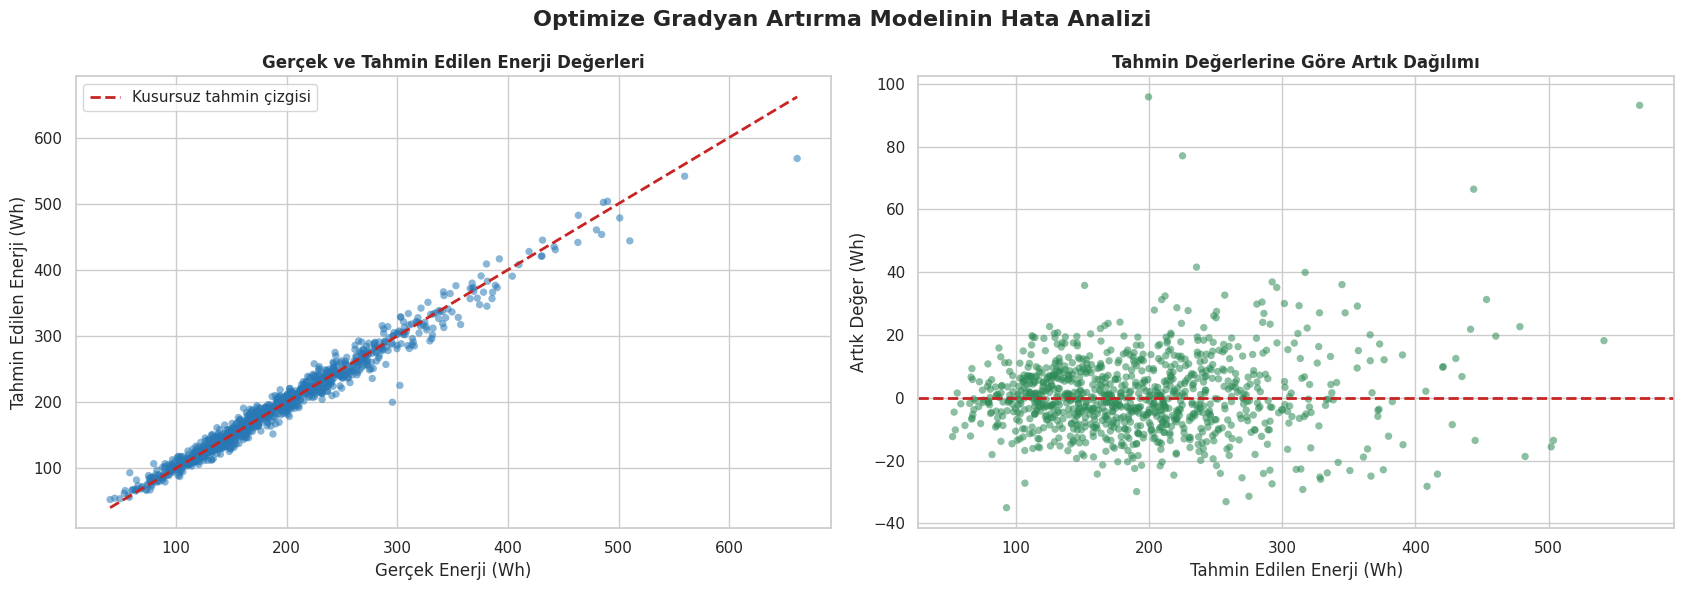

In [8]:
# Hata analizi ve görselleştirme için gerekli kütüphaneler içe aktarılıyor.
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin genel görünümü düzenleniyor.
sns.set_theme(
    style="whitegrid",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

# Test kümesindeki görev bilgileri tek bir analiz tablosunda birleştiriliyor.
hata_analizi_tablosu = X_test.copy()

hata_analizi_tablosu.insert(
    0,
    "gorev_no",
    gorev_no_test.astype(int)
)

hata_analizi_tablosu[
    "gercek_enerji_wh"
] = y_test.values

hata_analizi_tablosu[
    "tahmin_edilen_enerji_wh"
] = optimize_test_tahminleri

# Artık değer, gerçek enerjiden tahmin edilen enerjinin çıkarılmasıyla hesaplanıyor.
hata_analizi_tablosu[
    "artik_deger_wh"
] = (
    hata_analizi_tablosu["gercek_enerji_wh"]
    -
    hata_analizi_tablosu["tahmin_edilen_enerji_wh"]
)

# Mutlak hata ve mutlak yüzde hata değerleri hesaplanıyor.
hata_analizi_tablosu[
    "mutlak_hata_wh"
] = np.abs(
    hata_analizi_tablosu["artik_deger_wh"]
)

hata_analizi_tablosu[
    "mutlak_yuzde_hata"
] = (
    hata_analizi_tablosu["mutlak_hata_wh"]
    /
    hata_analizi_tablosu["gercek_enerji_wh"]
    * 100
)

# Hata dağılımının temel yüzdelik değerleri hesaplanıyor.
hata_yuzdelikleri = hata_analizi_tablosu[
    "mutlak_hata_wh"
].quantile(
    [
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1.00
    ]
)

hata_yuzdelik_tablosu = pd.DataFrame({
    "Yüzdelik": [
        "%25",
        "%50",
        "%75",
        "%90",
        "%95",
        "%99",
        "%100"
    ],
    "Mutlak Hata (Wh)": hata_yuzdelikleri.values
})

hata_yuzdelik_tablosu[
    "Mutlak Hata (Wh)"
] = hata_yuzdelik_tablosu[
    "Mutlak Hata (Wh)"
].round(2)

# Belirli hata sınırlarının altında kalan görev oranları hesaplanıyor.
hata_esik_tablosu = pd.DataFrame({
    "Hata Sınırı": [
        "5 Wh veya daha az",
        "10 Wh veya daha az",
        "15 Wh veya daha az",
        "20 Wh veya daha az",
        "30 Wh veya daha az"
    ],
    "Görev Sayısı": [
        (
            hata_analizi_tablosu["mutlak_hata_wh"] <= 5
        ).sum(),
        (
            hata_analizi_tablosu["mutlak_hata_wh"] <= 10
        ).sum(),
        (
            hata_analizi_tablosu["mutlak_hata_wh"] <= 15
        ).sum(),
        (
            hata_analizi_tablosu["mutlak_hata_wh"] <= 20
        ).sum(),
        (
            hata_analizi_tablosu["mutlak_hata_wh"] <= 30
        ).sum()
    ]
})

hata_esik_tablosu[
    "Test Kümesindeki Oranı (%)"
] = (
    hata_esik_tablosu["Görev Sayısı"]
    / len(hata_analizi_tablosu)
    * 100
).round(2)

# En yüksek mutlak hataya sahip on görev seçiliyor.
en_yuksek_hatali_gorevler = (
    hata_analizi_tablosu
    .sort_values(
        by="mutlak_hata_wh",
        ascending=False
    )
    .head(10)
    [
        [
            "gorev_no",
            "gorev_mesafesi_km",
            "ortalama_ucus_hizi_kmh",
            "operasyon_suresi_dk",
            "toplam_gorev_suresi_dk",
            "faydali_yuk_kg",
            "ruzgar_hizi_mps",
            "ortam_sicakligi_c",
            "batarya_sicakligi_c",
            "gercek_enerji_wh",
            "tahmin_edilen_enerji_wh",
            "artik_deger_wh",
            "mutlak_hata_wh",
            "mutlak_yuzde_hata"
        ]
    ]
    .copy()
)

# Tablo değerleri okunabilir biçimde yuvarlanıyor.
en_yuksek_hatali_gorevler = (
    en_yuksek_hatali_gorevler.round(2)
)

# Ortalama artık değeri kullanılarak genel tahmin yönü kontrol ediliyor.
ortalama_artik_deger = hata_analizi_tablosu[
    "artik_deger_wh"
].mean()

medyan_artik_deger = hata_analizi_tablosu[
    "artik_deger_wh"
].median()

# Sonuç tabloları görüntüleniyor.
print("NİHAİ MODEL HATA YÜZDELİKLERİ")
print("=" * 90)
display(hata_yuzdelik_tablosu)

print("\nHATA SINIRLARINA GÖRE GÖREV ORANLARI")
print("=" * 90)
display(hata_esik_tablosu)

print("\nGENEL ARTIK DEĞER KONTROLÜ")
print("=" * 90)
print(
    f"Ortalama artık değer: "
    f"{ortalama_artik_deger:.4f} Wh"
)
print(
    f"Medyan artık değer  : "
    f"{medyan_artik_deger:.4f} Wh"
)

print("\nEN YÜKSEK MUTLAK HATAYA SAHİP 10 GÖREV")
print("=" * 90)
display(en_yuksek_hatali_gorevler)

# Gerçek-tahmin ilişkisi ve artık değerler görselleştiriliyor.
sekil, eksenler = plt.subplots(
    1,
    2,
    figsize=(17, 6)
)

# Gerçek ve tahmin edilen enerji değerleri çiziliyor.
eksenler[0].scatter(
    hata_analizi_tablosu["gercek_enerji_wh"],
    hata_analizi_tablosu["tahmin_edilen_enerji_wh"],
    alpha=0.55,
    s=28,
    color="#2878B5",
    edgecolors="none"
)

# Kusursuz tahmini temsil eden referans çizgisi ekleniyor.
referans_alt_sinir = min(
    hata_analizi_tablosu["gercek_enerji_wh"].min(),
    hata_analizi_tablosu[
        "tahmin_edilen_enerji_wh"
    ].min()
)

referans_ust_sinir = max(
    hata_analizi_tablosu["gercek_enerji_wh"].max(),
    hata_analizi_tablosu[
        "tahmin_edilen_enerji_wh"
    ].max()
)

eksenler[0].plot(
    [
        referans_alt_sinir,
        referans_ust_sinir
    ],
    [
        referans_alt_sinir,
        referans_ust_sinir
    ],
    linestyle="--",
    linewidth=2,
    color="#C82423",
    label="Kusursuz tahmin çizgisi"
)

eksenler[0].set_title(
    "Gerçek ve Tahmin Edilen Enerji Değerleri"
)
eksenler[0].set_xlabel(
    "Gerçek Enerji (Wh)"
)
eksenler[0].set_ylabel(
    "Tahmin Edilen Enerji (Wh)"
)
eksenler[0].legend()

# Tahmin değerlerine göre artık değerler çiziliyor.
eksenler[1].scatter(
    hata_analizi_tablosu[
        "tahmin_edilen_enerji_wh"
    ],
    hata_analizi_tablosu["artik_deger_wh"],
    alpha=0.55,
    s=28,
    color="#2E8B57",
    edgecolors="none"
)

eksenler[1].axhline(
    y=0,
    color="#C82423",
    linestyle="--",
    linewidth=2
)

eksenler[1].set_title(
    "Tahmin Değerlerine Göre Artık Dağılımı"
)
eksenler[1].set_xlabel(
    "Tahmin Edilen Enerji (Wh)"
)
eksenler[1].set_ylabel(
    "Artık Değer (Wh)"
)

sekil.suptitle(
    "Optimize Gradyan Artırma Modelinin Hata Analizi",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


## 6. Özellik Önemlerinin İncelenmesi

Nihai modelin tahmin oluştururken hangi değişkenlerden daha fazla yararlandığını değerlendirmek amacıyla iki farklı özellik önemi yöntemi uygulanmıştır.

İlk yöntemde gradyan artırma modelinin ağaç yapılarından elde edilen yerleşik özellik önemleri kullanılmıştır. İkinci yöntemde ise test kümesindeki her özellik ayrı ayrı karıştırılmış ve bu işlemin modelin RMSE değerinde oluşturduğu artış ölçülmüştür. Bir özelliğin karıştırılması tahmin hatasını belirgin biçimde artırıyorsa, modelin o özellikten önemli ölçüde yararlandığı kabul edilmiştir.

Görev mesafesi, uçuş hızı ve toplam görev süresi arasında matematiksel bir ilişki bulunduğu unutulmamalıdır. Benzer şekilde ortam sıcaklığı ile batarya sıcaklığı güçlü biçimde ilişkilidir. Bu nedenle ilişkili değişkenlerin önem değerleri kendi aralarında paylaşılabilir. Özellik önemi sonuçları doğrudan fiziksel nedensellik olarak değil, modelin tahmin sürecindeki göreli kullanım düzeyi olarak yorumlanmıştır.


NİHAİ MODELİN ÖZELLİK ÖNEMLERİ


,Özellik,Yerleşik Önem,Permütasyon Sonrası RMSE Artışı (Wh),RMSE Artışı Standart Sapması,Yerleşik Önem (%)
0,toplam_gorev_suresi_dk,0.6974,78.7841,1.7025,69.7439
1,ruzgar_hizi_mps,0.0653,15.9406,0.6150,6.5308
2,faydali_yuk_kg,0.0243,7.2589,0.4223,2.4287
3,ortalama_ucus_hizi_kmh,0.0328,5.7393,0.3962,3.2826
4,ortam_sicakligi_c,0.0213,5.4058,0.3085,2.1277
5,gorev_mesafesi_km,0.1383,4.4687,0.3024,13.8297
6,batarya_sicakligi_c,0.0162,2.9173,0.1776,1.6222
7,operasyon_suresi_dk,0.0043,0.9505,0.1016,0.4344



ÖZELLİK ÖNEMİ KONTROLÜ
Yerleşik önem değerleri toplamı: 1.0000
En yüksek permütasyon önemine sahip özellik: toplam_gorev_suresi_dk


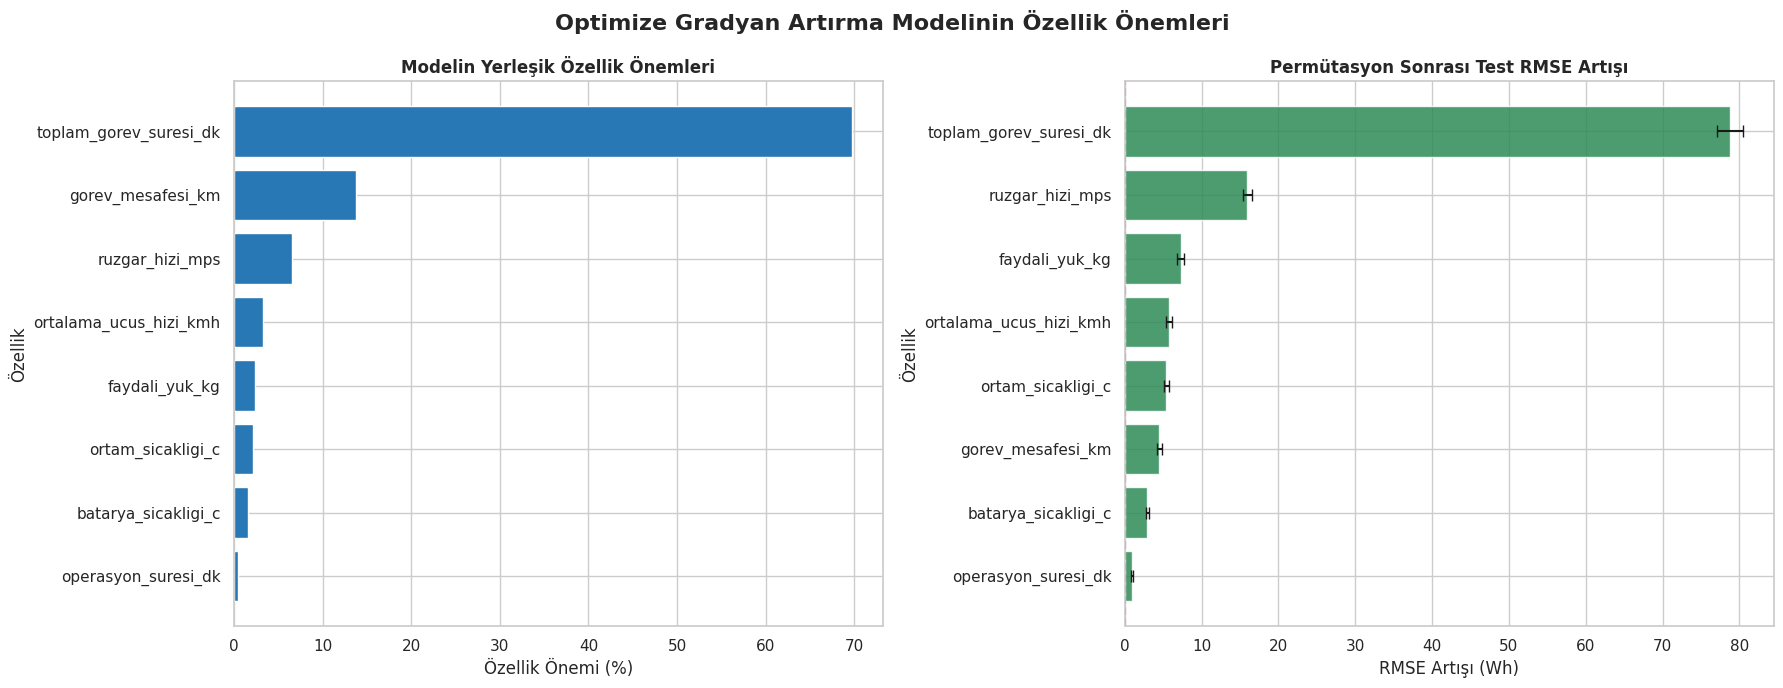

In [9]:
# Permütasyon temelli özellik önemi için gerekli araç içe aktarılıyor.
from sklearn.inspection import permutation_importance

# Gradyan artırma modelinin yerleşik özellik önemleri alınıyor.
yerlesik_onem_degerleri = (
    optimize_gradyan_artirma_modeli.feature_importances_
)

# Test verisi üzerinde permütasyon özellik önemi hesaplanıyor.
# Her özellik 30 kez karıştırılarak sonuçların kararlılığı inceleniyor.
permütasyon_sonuclari = permutation_importance(
    estimator=optimize_gradyan_artirma_modeli,
    X=X_test,
    y=y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=RASTGELELIK_DEGERI,
    n_jobs=-1
)

# İki yöntemin sonuçları ortak bir tabloda birleştiriliyor.
ozellik_onem_tablosu = pd.DataFrame({
    "Özellik": model_ozellikleri,
    "Yerleşik Önem": yerlesik_onem_degerleri,
    "Permütasyon Sonrası RMSE Artışı (Wh)": (
        permütasyon_sonuclari.importances_mean
    ),
    "RMSE Artışı Standart Sapması": (
        permütasyon_sonuclari.importances_std
    )
})

# Sonuçlar permütasyon sonrası RMSE artışına göre sıralanıyor.
ozellik_onem_tablosu = (
    ozellik_onem_tablosu
    .sort_values(
        by="Permütasyon Sonrası RMSE Artışı (Wh)",
        ascending=False
    )
    .reset_index(drop=True)
)

# Yerleşik önem değerleri yüzde biçimine dönüştürülüyor.
ozellik_onem_tablosu[
    "Yerleşik Önem (%)"
] = (
    ozellik_onem_tablosu["Yerleşik Önem"]
    * 100
)

# Sayısal değerler okunabilir biçimde yuvarlanıyor.
ozellik_onem_tablosu[
    [
        "Yerleşik Önem",
        "Yerleşik Önem (%)",
        "Permütasyon Sonrası RMSE Artışı (Wh)",
        "RMSE Artışı Standart Sapması"
    ]
] = ozellik_onem_tablosu[
    [
        "Yerleşik Önem",
        "Yerleşik Önem (%)",
        "Permütasyon Sonrası RMSE Artışı (Wh)",
        "RMSE Artışı Standart Sapması"
    ]
].round(4)

print("NİHAİ MODELİN ÖZELLİK ÖNEMLERİ")
print("=" * 90)
display(ozellik_onem_tablosu)

print("\nÖZELLİK ÖNEMİ KONTROLÜ")
print("=" * 90)
print(
    "Yerleşik önem değerleri toplamı: "
    f"{yerlesik_onem_degerleri.sum():.4f}"
)
print(
    "En yüksek permütasyon önemine sahip özellik: "
    f"{ozellik_onem_tablosu.iloc[0]['Özellik']}"
)

# Özellik önemlerinin görselleştirilmesi için grafik alanı oluşturuluyor.
sekil, eksenler = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

# Yerleşik özellik önemleri çiziliyor.
yerlesik_grafik_verisi = (
    ozellik_onem_tablosu
    .sort_values(
        by="Yerleşik Önem (%)",
        ascending=True
    )
)

eksenler[0].barh(
    yerlesik_grafik_verisi["Özellik"],
    yerlesik_grafik_verisi["Yerleşik Önem (%)"],
    color="#2878B5"
)

eksenler[0].set_title(
    "Modelin Yerleşik Özellik Önemleri"
)
eksenler[0].set_xlabel(
    "Özellik Önemi (%)"
)
eksenler[0].set_ylabel(
    "Özellik"
)

# Permütasyon sonrası RMSE artışları hata çubuklarıyla birlikte çiziliyor.
permutasyon_grafik_verisi = (
    ozellik_onem_tablosu
    .sort_values(
        by="Permütasyon Sonrası RMSE Artışı (Wh)",
        ascending=True
    )
)

eksenler[1].barh(
    permutasyon_grafik_verisi["Özellik"],
    permutasyon_grafik_verisi[
        "Permütasyon Sonrası RMSE Artışı (Wh)"
    ],
    xerr=permutasyon_grafik_verisi[
        "RMSE Artışı Standart Sapması"
    ],
    color="#2E8B57",
    alpha=0.85,
    capsize=4
)

eksenler[1].axvline(
    x=0,
    color="#C82423",
    linestyle="--",
    linewidth=1.5
)

eksenler[1].set_title(
    "Permütasyon Sonrası Test RMSE Artışı"
)
eksenler[1].set_xlabel(
    "RMSE Artışı (Wh)"
)
eksenler[1].set_ylabel(
    "Özellik"
)

sekil.suptitle(
    "Optimize Gradyan Artırma Modelinin Özellik Önemleri",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


## 7. Nihai Modelin ve Değerlendirme Sonuçlarının Kaydedilmesi

Hiperparametre optimizasyonu tamamlanan ve bağımsız test kümesi üzerinde değerlendirilen gradyan artırma modeli kalıcı olarak kaydedilmiştir. Model dosyasına ek olarak kullanılan özellik sırası, hiperparametreler, test başarı ölçütleri ve veri dosyasının SHA-256 değeri bir metadata dosyasında saklanmıştır.

Çapraz doğrulama sonuçları, nihai model karşılaştırması, özellik önemleri ve test kümesine ait tahmin sonuçları ayrı CSV dosyalarına kaydedilmiştir. Böylece sonraki karar destek ve kullanıcı arayüzü aşamalarında modelin yeniden eğitilmesine gerek kalmadan aynı model ve aynı sonuçlar kullanılabilecektir.

Kaydedilen model, bağımsız test değerlendirmesinin yapıldığı eğitim kümesiyle eğitilmiş sürümdür. Bu tercih, raporlanan performans sonuçlarıyla kullanılan model dosyasının doğrudan uyumlu kalmasını sağlamaktadır.


In [10]:
# Model ve sonuç dosyalarının kaydedilmesi için gerekli kütüphaneler içe aktarılıyor.
import json
import hashlib
import joblib

# Kaydedilecek dosyaların yolları tanımlanıyor.
NIHAI_MODEL_DOSYASI = (
    MODEL_KLASORU / "optimize_gradyan_artirma_modeli.joblib"
)

MODEL_METADATA_DOSYASI = (
    MODEL_KLASORU / "model_metadata.json"
)

CAPRAZ_DOGRULAMA_DOSYASI = (
    SONUC_KLASORU / "capraz_dogrulama_sonuclari.csv"
)

NIHAI_KARSILASTIRMA_DOSYASI = (
    SONUC_KLASORU / "nihai_model_karsilastirmasi.csv"
)

OZELLIK_ONEM_DOSYASI = (
    SONUC_KLASORU / "ozellik_onemleri.csv"
)

TEST_TAHMIN_DOSYASI = (
    SONUC_KLASORU / "test_kumesi_tahminleri.csv"
)

HIPERPARAMETRE_DOSYASI = (
    SONUC_KLASORU / "hiperparametre_arama_sonuclari.csv"
)

# Optimize edilmiş model Joblib biçiminde kaydediliyor.
joblib.dump(
    optimize_gradyan_artirma_modeli,
    NIHAI_MODEL_DOSYASI
)

# Sonuç tabloları CSV dosyalarına kaydediliyor.
capraz_dogrulama_sonuclari.to_csv(
    CAPRAZ_DOGRULAMA_DOSYASI,
    index=False,
    encoding="utf-8-sig"
)

nihai_model_karsilastirmasi.to_csv(
    NIHAI_KARSILASTIRMA_DOSYASI,
    index=False,
    encoding="utf-8-sig"
)

ozellik_onem_tablosu.to_csv(
    OZELLIK_ONEM_DOSYASI,
    index=False,
    encoding="utf-8-sig"
)

en_iyi_on_parametre.to_csv(
    HIPERPARAMETRE_DOSYASI,
    index=False,
    encoding="utf-8-sig"
)

# Test tahminleri kaydedilmeden önce sütunlar Türkçe ve okunabilir biçimde hazırlanıyor.
kaydedilecek_test_tahminleri = hata_analizi_tablosu.copy()

kaydedilecek_test_tahminleri.to_csv(
    TEST_TAHMIN_DOSYASI,
    index=False,
    encoding="utf-8-sig"
)

# Model dosyasının SHA-256 özet değeri hesaplanıyor.
model_sha256_hesaplayici = hashlib.sha256()

with open(NIHAI_MODEL_DOSYASI, "rb") as model_dosyasi:
    for veri_blogu in iter(
        lambda: model_dosyasi.read(8192),
        b""
    ):
        model_sha256_hesaplayici.update(veri_blogu)

model_sha256 = model_sha256_hesaplayici.hexdigest()

# Model metadata bilgileri hazırlanıyor.
model_metadata = {
    "model_adi": "Optimize Gradyan Artırma Regresyonu",
    "model_sinifi": (
        optimize_gradyan_artirma_modeli.__class__.__name__
    ),
    "scikit_learn_surumu": sklearn.__version__,
    "rastgelelik_degeri": int(RASTGELELIK_DEGERI),
    "egitim_kaydi_sayisi": int(len(X_egitim)),
    "test_kaydi_sayisi": int(len(X_test)),
    "model_ozellikleri": model_ozellikleri,
    "hedef_degisken": hedef_degisken,
    "en_iyi_hiperparametreler": {
        parametre: (
            deger.item()
            if isinstance(deger, np.generic)
            else deger
        )
        for parametre, deger
        in en_iyi_parametreler.items()
    },
    "capraz_dogrulama_rmse_wh": round(
        float(en_iyi_cv_rmse),
        4
    ),
    "test_mae_wh": round(
        float(optimize_test_mae),
        4
    ),
    "test_rmse_wh": round(
        float(optimize_test_rmse),
        4
    ),
    "test_r2": round(
        float(optimize_test_r2),
        4
    ),
    "en_buyuk_mutlak_test_hatasi_wh": round(
        float(
            hata_analizi_tablosu[
                "mutlak_hata_wh"
            ].max()
        ),
        4
    ),
    "temiz_veri_sha256": (
        hesaplanan_temiz_veri_sha256
    ),
    "model_sha256": model_sha256,
    "veri_turu": "Sentetik görev verisi",
    "model_kullanim_notu": (
        "Model bir kavram kanıtlama çalışmasıdır. "
        "Gerçek sistemde kullanılmadan önce gerçek cihaz "
        "verileriyle yeniden eğitilmeli ve doğrulanmalıdır."
    )
}

# Metadata dosyası Türkçe karakterler korunarak kaydediliyor.
with open(
    MODEL_METADATA_DOSYASI,
    "w",
    encoding="utf-8"
) as metadata_dosyasi:
    json.dump(
        model_metadata,
        metadata_dosyasi,
        ensure_ascii=False,
        indent=4
    )

# Kaydedilen model tekrar yükleniyor.
yuklenen_model = joblib.load(
    NIHAI_MODEL_DOSYASI
)

# Yüklenen modelin tahminleri kayıt öncesindeki tahminlerle karşılaştırılıyor.
yuklenen_model_tahminleri = yuklenen_model.predict(
    X_test
)

en_buyuk_tahmin_farki = float(
    np.max(
        np.abs(
            yuklenen_model_tahminleri
            - optimize_test_tahminleri
        )
    )
)

model_kaydi_dogrulandi = (
    en_buyuk_tahmin_farki < 1e-12
)

if not model_kaydi_dogrulandi:
    raise ValueError(
        "Kaydedilen modelin tahminleri özgün modelle eşleşmedi."
    )

# Kayıt sonuçları görüntüleniyor.
print("NİHAİ MODEL VE SONUÇLAR BAŞARIYLA KAYDEDİLDİ")
print("=" * 90)
print(f"Model dosyası        : {NIHAI_MODEL_DOSYASI.name}")
print(f"Metadata dosyası     : {MODEL_METADATA_DOSYASI.name}")
print(f"Çapraz doğrulama     : {CAPRAZ_DOGRULAMA_DOSYASI.name}")
print(f"Model karşılaştırması: {NIHAI_KARSILASTIRMA_DOSYASI.name}")
print(f"Özellik önemleri     : {OZELLIK_ONEM_DOSYASI.name}")
print(f"Test tahminleri      : {TEST_TAHMIN_DOSYASI.name}")
print(f"Hiperparametre özeti : {HIPERPARAMETRE_DOSYASI.name}")

print("\nMODEL DOSYASI DOĞRULAMA SONUÇLARI")
print("=" * 90)
print(
    f"Model dosyası mevcut : "
    f"{NIHAI_MODEL_DOSYASI.exists()}"
)
print(
    f"Model dosyası boyutu : "
    f"{NIHAI_MODEL_DOSYASI.stat().st_size / 1024:.2f} KB"
)
print(
    f"En büyük tahmin farkı: "
    f"{en_buyuk_tahmin_farki:.12f}"
)
print(
    f"Model kaydı doğrulandı: "
    f"{model_kaydi_dogrulandi}"
)
print(f"Model SHA-256         : {model_sha256}")


NİHAİ MODEL VE SONUÇLAR BAŞARIYLA KAYDEDİLDİ
Model dosyası        : optimize_gradyan_artirma_modeli.joblib
Metadata dosyası     : model_metadata.json
Çapraz doğrulama     : capraz_dogrulama_sonuclari.csv
Model karşılaştırması: nihai_model_karsilastirmasi.csv
Özellik önemleri     : ozellik_onemleri.csv
Test tahminleri      : test_kumesi_tahminleri.csv
Hiperparametre özeti : hiperparametre_arama_sonuclari.csv

MODEL DOSYASI DOĞRULAMA SONUÇLARI
Model dosyası mevcut : True
Model dosyası boyutu : 832.35 KB
En büyük tahmin farkı: 0.000000000000
Model kaydı doğrulandı: True
Model SHA-256         : bd776e7034c7fdaa83c5a80f59c0b46836828f1b9a3a9f28d6bce6d20ed75fa5


## 8. Sonuç

Bu çalışmada, Droneport destekli İHA görevlerinin enerji ihtiyacını tahmin etmek amacıyla farklı regresyon yöntemleri geliştirilmiş ve karşılaştırılmıştır.

Yalnızca toplam görev süresini kullanan temel model test kümesinde 30,3309 Wh RMSE ve 0,8551 R² sonucu vermiştir. Görev ve çevre özelliklerinin tamamı kullanıldığında doğrusal regresyon, karar ağacı, rastgele orman ve gradyan artırma modellerinin tahmin başarıları incelenmiştir.

Beş katlı çapraz doğrulama sonucunda gradyan artırma modeli en başarılı yöntem olarak belirlenmiştir. Hiperparametre optimizasyonundan sonra modelin çapraz doğrulama RMSE değeri 13,2611 Wh değerinden 12,2627 Wh değerine düşürülmüş ve %7,53 oranında iyileşme sağlanmıştır.

Optimize edilen model, hiperparametre seçiminde kullanılmayan 1.000 görevlik bağımsız test kümesinde aşağıdaki sonuçları vermiştir:

- **MAE:** 8,9065 Wh
- **RMSE:** 12,3851 Wh
- **R²:** 0,9758

Test görevlerinin %66'sında mutlak tahmin hatası 10 Wh veya daha az, %92,1'inde ise 20 Wh veya daha az olarak hesaplanmıştır. Modelin en büyük hatası, veri kümesindeki tek 600 Wh üzeri görevde görülmüştür. Bu sonuç, modelin veri aralığının dışına yakın uç koşullarda daha dikkatli kullanılması gerektiğini göstermiştir.

Özellik önemi analizinde toplam görev süresi en etkili değişken olarak belirlenmiştir. Rüzgâr hızı, faydalı yük ağırlığı, ortalama uçuş hızı ve ortam sıcaklığının da tahmin başarısına anlamlı katkı sağladığı gözlemlenmiştir.

Nihai model ve değerlendirme sonuçları kalıcı olarak kaydedilmiştir. Bir sonraki aşamada bu model kullanılarak batarya kapasitesi, başlangıç doluluk oranı ve güvenli rezerv koşullarını değerlendiren görev karar destek ve optimizasyon sistemi geliştirilecektir.

Geliştirilen model sentetik verilerle hazırlanmış bir kavram kanıtlama çalışmasıdır. Modelin gerçek bir Droneport veya İHA sisteminde kullanılabilmesi için gerçek cihaz verileriyle yeniden eğitilmesi, doğrulanması ve güvenlik testlerinden geçirilmesi gerekmektedir.
